# Sleep stage classification: all models

Models included:
- Headband tabular: Logistic Regression, Linear SVM, Random Forest
- PSG tabular: Logistic Regression, Linear SVM, Random Forest
- Headband CNN: spectrogram only
- PSG CNN: spectrogram only
- PSG fusion: PSG spectrogram + selected PPG features only

Notes:
- Uses streaming spectrogram loading to avoid large RAM allocations.
- Collapses labels to a 3-class task: Wake (0), NonREM (1/2/3 -> 1), REM (4 -> 2).
- No class-imbalance weighting is used.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import Sequence

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_ROOT = Path("../data/features")
print("cwd:", Path.cwd())
print("DATA_ROOT:", DATA_ROOT.resolve())
if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Could not find {DATA_ROOT.resolve()} -- set DATA_ROOT to your dataset path.")

PPG_FEATURE_COLS = [
    "ppg_RMSSD",
    "ppg_SDNN",
    "ppg_HR_mean_bpm",
    "ppg_n_beats",
    "ppg_pulse_amp_mean",
    "ppg_pulse_amp_std",
]
META_COLS = ["subject", "subject_id", "acq", "epoch_idx", "onset", "duration", "stage_hum"]


STAGE_MAP = {0: 0, 1: 1, 2: 1, 3: 1, 4: 2}
STAGE_NAMES = ["Wake", "NonREM", "REM"]


cwd: e:\UW\EE 344\Project\scripts
DATA_ROOT: E:\UW\EE 344\Project\data\features


In [2]:
def read_parquet(path):
    try:
        return pd.read_parquet(path, engine="pyarrow")
    except Exception:
        return pd.read_parquet(path)


def collapse_stage(series):
    return series.map(STAGE_MAP)


def build_manifest(data_root=DATA_ROOT):
    rows = []
    subject_dirs = sorted([p for p in Path(data_root).iterdir() if p.is_dir() and p.name.startswith("sub-")])

    for subject_dir in subject_dirs:
        subject_id = subject_dir.name
        for device in ["headband", "psg"]:
            device_dir = subject_dir / device
            feat_path = device_dir / "features.parquet"
            spec_path = device_dir / "spectrogram.npy"
            if not (feat_path.exists() and spec_path.exists()):
                continue

            df = read_parquet(feat_path).copy()
            if "subject_id" not in df.columns:
                df["subject_id"] = subject_id

            spec_shape = np.load(spec_path, mmap_mode="r").shape
            n = min(len(df), spec_shape[0])
            df = df.iloc[:n].copy().reset_index(drop=True)
            df["stage_collapsed"] = collapse_stage(df["stage_hum"])
            df = df[df["stage_collapsed"].notna()].copy().reset_index(drop=True)
            if len(df) == 0:
                continue
            df["stage_collapsed"] = df["stage_collapsed"].astype(int)
            df["row_idx"] = df.index.astype(int)
            df["device"] = device
            df["spec_path"] = str(spec_path)
            rows.append(df)

    if not rows:
        raise ValueError("No valid subject/device rows found under DATA_ROOT.")

    manifest = pd.concat(rows, ignore_index=True)
    return manifest

manifest = build_manifest(DATA_ROOT)
print("rows in manifest:", len(manifest))
print("devices:", manifest["device"].value_counts().to_dict())
print("collapsed labels:", manifest["stage_collapsed"].value_counts().sort_index().to_dict())



rows in manifest: 104756
devices: {'headband': 52378, 'psg': 52378}
collapsed labels: {0: 16214, 1: 71818, 2: 16724}


In [3]:

# shared subject split so comparisons are fair
subjects_headband = set(manifest.loc[manifest.device == "headband", "subject_id"].unique())
subjects_psg = set(manifest.loc[manifest.device == "psg", "subject_id"].unique())
shared_subjects = sorted(subjects_headband & subjects_psg)
print("shared subjects:", len(shared_subjects))

train_subjects, test_subjects = train_test_split(shared_subjects, test_size=0.2, random_state=SEED)
print("train subjects:", len(train_subjects), "test subjects:", len(test_subjects))


shared subjects: 56
train subjects: 44 test subjects: 12


In [4]:
def summarize_labels(df, name):
    print(f"\n{name}")
    counts = df["stage_collapsed"].value_counts().sort_index()
    counts.index = [STAGE_NAMES[i] for i in counts.index]
    print(counts)

for device in ["headband", "psg"]:
    df_train = manifest[(manifest.device == device) & (manifest.subject_id.isin(train_subjects))]
    df_test = manifest[(manifest.device == device) & (manifest.subject_id.isin(test_subjects))]
    summarize_labels(df_train, f"{device} train labels")
    summarize_labels(df_test, f"{device} test labels")



headband train labels
Wake       6390
NonREM    28147
REM        6695
Name: count, dtype: int64

headband test labels
Wake      1717
NonREM    7762
REM       1667
Name: count, dtype: int64

psg train labels
Wake       6390
NonREM    28147
REM        6695
Name: count, dtype: int64

psg test labels
Wake      1717
NonREM    7762
REM       1667
Name: count, dtype: int64


In [5]:
def get_tabular_xy(manifest, device, subjects, ppg_only=False):
    df = manifest[(manifest.device == device) & (manifest.subject_id.isin(subjects))].copy().reset_index(drop=True)
    y = df["stage_collapsed"].astype(int).to_numpy()

    if ppg_only:
        X = df[PPG_FEATURE_COLS].astype(np.float32).to_numpy()
    else:
        numeric_cols = [c for c in df.select_dtypes(include="number").columns if c not in ["stage_hum", "stage_collapsed", "row_idx"]]
        X = df[numeric_cols].astype(np.float32).to_numpy()
    return X, y


def encode_labels(y_train, y_test):
    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)
    y_test_enc = le.transform(y_test)
    return y_train_enc, y_test_enc, le


def report_results(name, y_true, y_pred, labels=None):
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))

    target_names = [STAGE_NAMES[int(x)] for x in labels]

    print(f"\n===== {name} =====")
    print(classification_report(y_true, y_pred, labels=labels, target_names=target_names, zero_division=0))
    bal = balanced_accuracy_score(y_true, y_pred)
    macro = f1_score(y_true, y_pred, average="macro")
    print("balanced_accuracy:", round(bal, 4))
    print("macro_f1:", round(macro, 4))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=target_names, yticklabels=target_names)
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    return {"model": name, "balanced_accuracy": bal, "macro_f1": macro}



===== headband_logistic_regression =====
              precision    recall  f1-score   support

        Wake       0.75      0.30      0.43      1717
      NonREM       0.73      0.95      0.83      7762
         REM       0.26      0.06      0.10      1667

    accuracy                           0.72     11146
   macro avg       0.58      0.44      0.45     11146
weighted avg       0.67      0.72      0.66     11146

balanced_accuracy: 0.4391
macro_f1: 0.4541


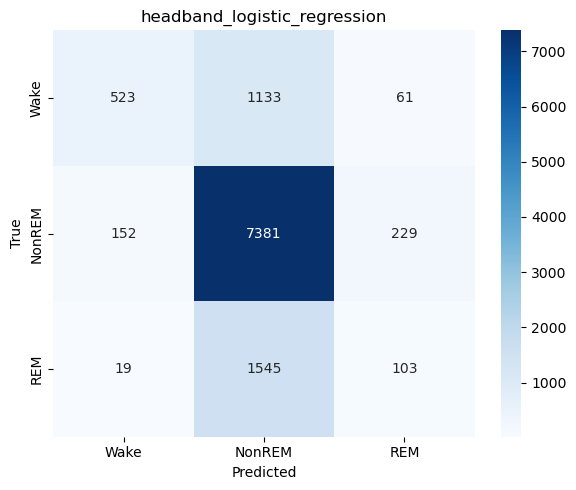


===== headband_linear_svm =====
              precision    recall  f1-score   support

        Wake       0.76      0.25      0.38      1717
      NonREM       0.73      0.97      0.83      7762
         REM       0.24      0.03      0.06      1667

    accuracy                           0.72     11146
   macro avg       0.57      0.42      0.42     11146
weighted avg       0.66      0.72      0.64     11146

balanced_accuracy: 0.4176
macro_f1: 0.4215


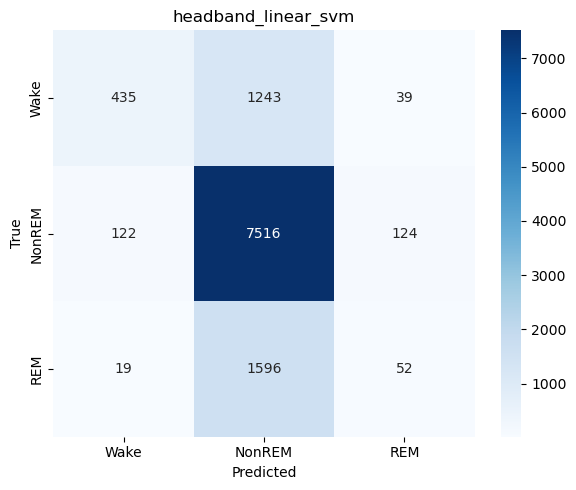


===== headband_random_forest =====
              precision    recall  f1-score   support

        Wake       0.72      0.66      0.69      1717
      NonREM       0.81      0.85      0.83      7762
         REM       0.39      0.34      0.37      1667

    accuracy                           0.74     11146
   macro avg       0.64      0.62      0.63     11146
weighted avg       0.74      0.74      0.74     11146

balanced_accuracy: 0.6178
macro_f1: 0.6289


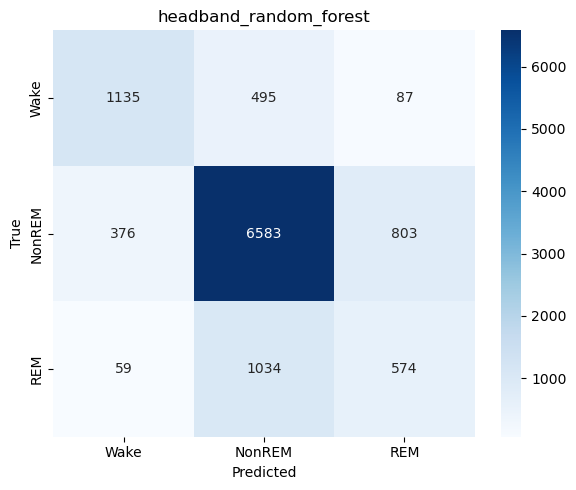


===== psg_logistic_regression =====
              precision    recall  f1-score   support

        Wake       0.74      0.63      0.68      1717
      NonREM       0.78      0.94      0.85      7762
         REM       0.40      0.08      0.14      1667

    accuracy                           0.77     11146
   macro avg       0.64      0.55      0.56     11146
weighted avg       0.72      0.77      0.72     11146

balanced_accuracy: 0.5527
macro_f1: 0.5589


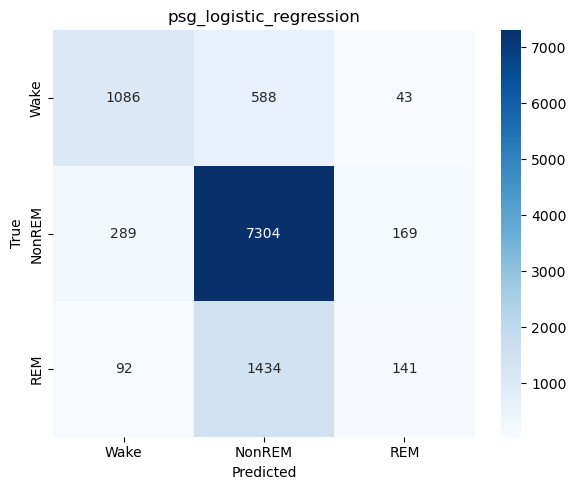


===== psg_linear_svm =====
              precision    recall  f1-score   support

        Wake       0.73      0.61      0.66      1717
      NonREM       0.77      0.95      0.85      7762
         REM       0.44      0.05      0.08      1667

    accuracy                           0.76     11146
   macro avg       0.65      0.54      0.53     11146
weighted avg       0.72      0.76      0.71     11146

balanced_accuracy: 0.5351
macro_f1: 0.5333


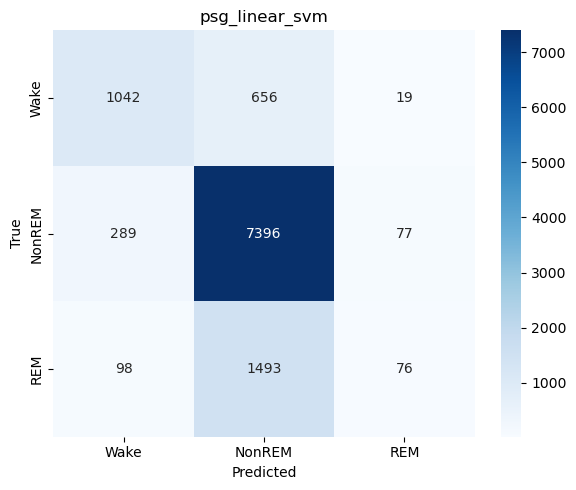


===== psg_random_forest =====
              precision    recall  f1-score   support

        Wake       0.80      0.80      0.80      1717
      NonREM       0.84      0.91      0.87      7762
         REM       0.55      0.32      0.40      1667

    accuracy                           0.81     11146
   macro avg       0.73      0.68      0.69     11146
weighted avg       0.79      0.81      0.79     11146

balanced_accuracy: 0.6776
macro_f1: 0.6924


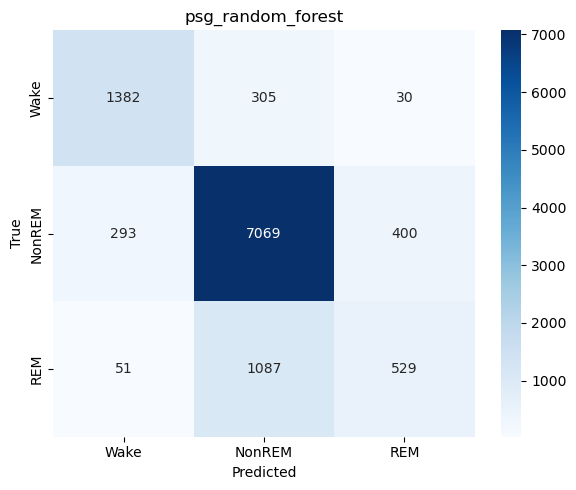

In [6]:
def run_tabular_models(manifest, device):
    X_train, y_train = get_tabular_xy(manifest, device, train_subjects)
    X_test, y_test = get_tabular_xy(manifest, device, test_subjects)
    y_train_enc, y_test_enc, le = encode_labels(y_train, y_test)

    models = {
        "logistic_regression": LogisticRegression(max_iter=2000, solver="lbfgs"),
        "linear_svm": LinearSVC(C=1.0, max_iter=5000),
        "random_forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    }

    results = []
    for name, model in models.items():
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", model),
        ])
        pipe.fit(X_train, y_train_enc)
        y_pred = pipe.predict(X_test)
        results.append(report_results(f"{device}_{name}", y_test_enc, y_pred, labels=le.classes_))
    return results

results = []
results += run_tabular_models(manifest, "headband")
results += run_tabular_models(manifest, "psg")


In [7]:

class SpectrogramSequence(Sequence):
    def __init__(self, df, batch_size=16, shuffle=True, ppg_cols=None):
        self.df = df.reset_index(drop=True).copy()
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.ppg_cols = ppg_cols
        self.indices = np.arange(len(self.df))
        self.le = None
        self._memmaps = {}
        self.on_epoch_end()

    def set_label_encoder(self, le):
        self.le = le

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def _get_mmap(self, path):
        path = str(path)
        if path not in self._memmaps:
            self._memmaps[path] = np.load(path, mmap_mode="r")
        return self._memmaps[path]

    def __getitem__(self, idx):
        batch_ids = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch = self.df.iloc[batch_ids]

        x_specs = []
        for _, row in batch.iterrows():
            arr = self._get_mmap(row["spec_path"])[int(row["row_idx"])]  # (C, F, T)
            arr = np.transpose(arr, (1, 2, 0)).astype(np.float32)          # (F, T, C)
            x_specs.append(arr)
        x_specs = np.stack(x_specs, axis=0)

        y = batch["stage_collapsed"].astype(int).to_numpy()
        if self.le is not None:
            y = self.le.transform(y)

        if self.ppg_cols is None:
            return x_specs, y

        x_tab = batch[self.ppg_cols].astype(np.float32).to_numpy()
        return {"spec_input": x_specs, "tab_input": x_tab}, y


In [8]:
def build_cnn_model(input_shape, num_classes, lr=3e-4):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_fusion_model(spec_shape, tab_dim, num_classes, lr=3e-4):
    spec_input = keras.Input(shape=spec_shape, name="spec_input")
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(spec_input)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    tab_input = keras.Input(shape=(tab_dim,), name="tab_input")
    y = layers.Dense(32, activation="relu")(tab_input)
    y = layers.Dropout(0.2)(y)
    y = layers.Dense(16, activation="relu")(y)

    z = layers.Concatenate()([x, y])
    z = layers.Dense(64, activation="relu")(z)
    z = layers.Dropout(0.3)(z)
    out = layers.Dense(num_classes, activation="softmax")(z)
    model = keras.Model([spec_input, tab_input], out)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    ]


def plot_history(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title(f"{title} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()


Epoch 1/30
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - accuracy: 0.6942 - loss: 0.7921 - val_accuracy: 0.7295 - val_loss: 0.6339 - learning_rate: 3.0000e-04
Epoch 2/30
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 33s 6ms/step - accuracy: 0.7759 - loss: 0.5364 - val_accuracy: 0.7666 - val_loss: 0.5741 - learning_rate: 3.0000e-04
Epoch 3/30
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 33s 6ms/step - accuracy: 0.7978 - loss: 0.4713 - val_accuracy: 0.7781 - val_loss: 0.5114 - learning_rate: 3.0000e-04
Epoch 4/30
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - accuracy: 0.8088 - loss: 0.4451 - val_accuracy: 0.7895 - val_loss: 0.5160 - learning_rate: 3.0000e-04
Epoch 5/30
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 33s 6ms/step - accuracy: 0.8184 - loss: 0.4218 - val_accuracy: 0.8041 - val_loss: 0.4752 - learning_rate: 3.0000e-04
Epoch 6/30
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 33s 6ms/step - accuracy: 0.8266 - loss: 0.4065 - val_accuracy: 0.8000 - val_loss: 0.4750 - learning_rate: 3.0000e-04
Epoch 7/30
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 32s 

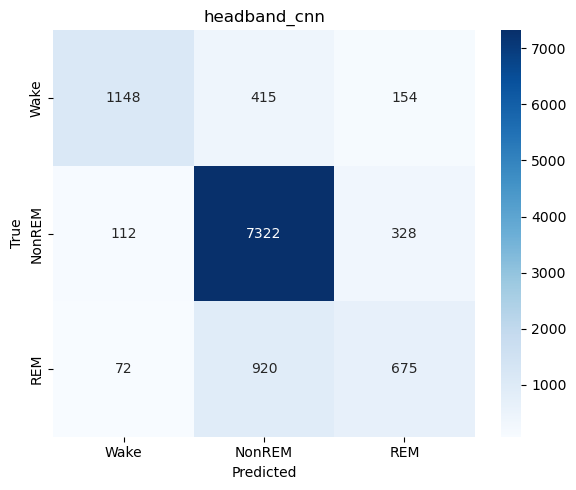

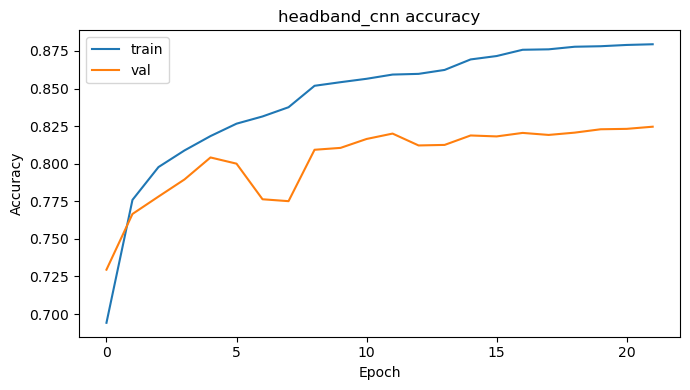

Epoch 1/30
10308/10308 ━━━━━━━━━━━━━━━━━━━━ 76s 7ms/step - accuracy: 0.7246 - loss: 0.7349 - val_accuracy: 0.7659 - val_loss: 0.6045 - learning_rate: 3.0000e-04
Epoch 2/30
10308/10308 ━━━━━━━━━━━━━━━━━━━━ 61s 6ms/step - accuracy: 0.8200 - loss: 0.4376 - val_accuracy: 0.8172 - val_loss: 0.4502 - learning_rate: 3.0000e-04
Epoch 3/30
10308/10308 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step - accuracy: 0.8461 - loss: 0.3804 - val_accuracy: 0.7726 - val_loss: 0.4958 - learning_rate: 3.0000e-04
Epoch 4/30
10308/10308 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step - accuracy: 0.8590 - loss: 0.3453 - val_accuracy: 0.8197 - val_loss: 0.4612 - learning_rate: 3.0000e-04
Epoch 5/30
10308/10308 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step - accuracy: 0.8767 - loss: 0.3044 - val_accuracy: 0.8423 - val_loss: 0.4193 - learning_rate: 1.5000e-04
Epoch 6/30
10308/10308 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step - accuracy: 0.8839 - loss: 0.2893 - val_accuracy: 0.8390 - val_loss: 0.4002 - learning_rate: 1.5000e-04
Epoch 7/30
10308/10308 ━━━━━━━━━━━

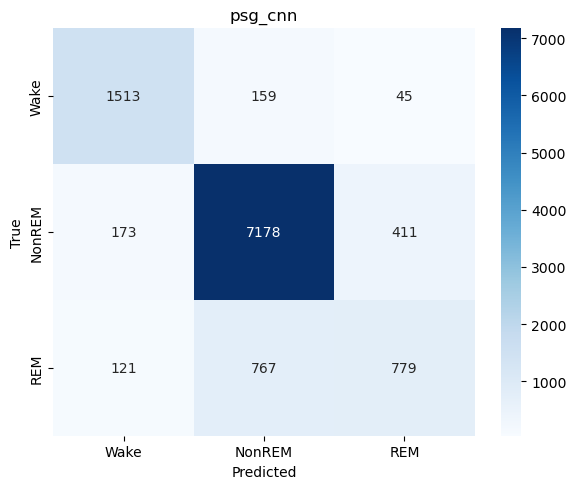

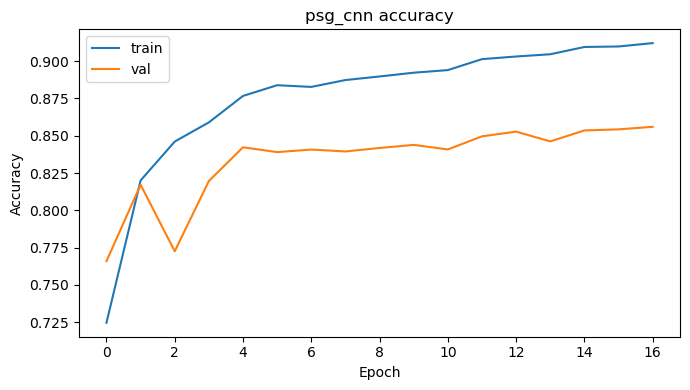

In [9]:
def get_input_shape_for_device(manifest, device):
    row = manifest[manifest.device == device].iloc[0]
    arr = np.load(row["spec_path"], mmap_mode="r")[int(row["row_idx"])]
    arr = np.transpose(arr, (1, 2, 0)).astype(np.float32)
    return arr.shape


def train_eval_cnn(manifest, device, epochs=30, batch_size=8, lr=3e-4):
    train_df = manifest[(manifest.device == device) & (manifest.subject_id.isin(train_subjects))].copy()
    test_df = manifest[(manifest.device == device) & (manifest.subject_id.isin(test_subjects))].copy()

    le = LabelEncoder()
    le.fit(train_df["stage_collapsed"].astype(int))

    train_seq = SpectrogramSequence(train_df, batch_size=batch_size, shuffle=True)
    val_seq = SpectrogramSequence(test_df, batch_size=batch_size, shuffle=False)
    train_seq.set_label_encoder(le)
    val_seq.set_label_encoder(le)

    model = build_cnn_model(get_input_shape_for_device(manifest, device), len(le.classes_), lr=lr)
    history = model.fit(
        train_seq,
        validation_data=val_seq,
        epochs=epochs,
        callbacks=make_callbacks(),
        verbose=1,
    )

    y_true = le.transform(test_df["stage_collapsed"].astype(int))
    y_prob = model.predict(val_seq, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    result = report_results(f"{device}_cnn", y_true, y_pred, labels=le.classes_)
    plot_history(history, f"{device}_cnn")
    return result

results.append(train_eval_cnn(manifest, "headband", epochs=30, batch_size=8, lr=3e-4))
results.append(train_eval_cnn(manifest, "psg", epochs=30, batch_size=4, lr=3e-4))


Epoch 1/30
10308/10308 ━━━━━━━━━━━━━━━━━━━━ 82s 7ms/step - accuracy: 0.6721 - loss: 0.9856 - val_accuracy: 0.7580 - val_loss: 0.5496 - learning_rate: 3.0000e-04
Epoch 2/30
10308/10308 ━━━━━━━━━━━━━━━━━━━━ 73s 7ms/step - accuracy: 0.7949 - loss: 0.4794 - val_accuracy: 0.8203 - val_loss: 0.4193 - learning_rate: 3.0000e-04
Epoch 3/30
10308/10308 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - accuracy: 0.8415 - loss: 0.3850 - val_accuracy: 0.8050 - val_loss: 0.5202 - learning_rate: 3.0000e-04
Epoch 4/30
10308/10308 ━━━━━━━━━━━━━━━━━━━━ 76s 7ms/step - accuracy: 0.8584 - loss: 0.3489 - val_accuracy: 0.8315 - val_loss: 0.4333 - learning_rate: 3.0000e-04
Epoch 5/30
10308/10308 ━━━━━━━━━━━━━━━━━━━━ 73s 7ms/step - accuracy: 0.8732 - loss: 0.3060 - val_accuracy: 0.8439 - val_loss: 0.3843 - learning_rate: 1.5000e-04
Epoch 6/30
10308/10308 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - accuracy: 0.8813 - loss: 0.2934 - val_accuracy: 0.8294 - val_loss: 0.4506 - learning_rate: 1.5000e-04
Epoch 7/30
10308/10308 ━━━━━━━━━━━

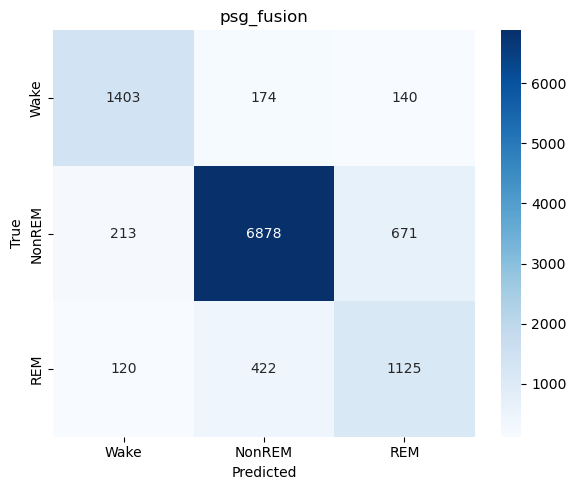

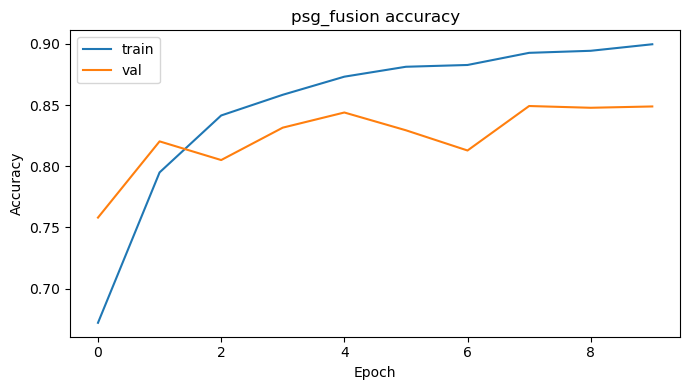

In [10]:
def train_eval_psg_fusion(manifest, epochs=30, batch_size=4, lr=3e-4):
    train_df = manifest[(manifest.device == "psg") & (manifest.subject_id.isin(train_subjects))].copy()
    test_df = manifest[(manifest.device == "psg") & (manifest.subject_id.isin(test_subjects))].copy()

    le = LabelEncoder()
    le.fit(train_df["stage_collapsed"].astype(int))

    train_seq = SpectrogramSequence(train_df, batch_size=batch_size, shuffle=True, ppg_cols=PPG_FEATURE_COLS)
    val_seq = SpectrogramSequence(test_df, batch_size=batch_size, shuffle=False, ppg_cols=PPG_FEATURE_COLS)
    train_seq.set_label_encoder(le)
    val_seq.set_label_encoder(le)

    model = build_fusion_model(get_input_shape_for_device(manifest, "psg"), len(PPG_FEATURE_COLS), len(le.classes_), lr=lr)
    history = model.fit(
        train_seq,
        validation_data=val_seq,
        epochs=epochs,
        callbacks=make_callbacks(),
        verbose=1,
    )

    y_true = le.transform(test_df["stage_collapsed"].astype(int))
    y_prob = model.predict(val_seq, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    result = report_results("psg_fusion", y_true, y_pred, labels=le.classes_)
    plot_history(history, "psg_fusion")
    return result

results.append(train_eval_psg_fusion(manifest, epochs=30, batch_size=4, lr=3e-4))


In [11]:
results_df = pd.DataFrame(results).sort_values(["balanced_accuracy", "macro_f1"], ascending=False).reset_index(drop=True)
print(results_df)
results_df



                          model  balanced_accuracy  macro_f1
0                    psg_fusion           0.792700  0.779989
1                       psg_cnn           0.757752  0.766794
2             psg_random_forest           0.677649  0.692387
3                  headband_cnn           0.672280  0.707658
4        headband_random_forest           0.617825  0.628887
5       psg_logistic_regression           0.552692  0.558878
6                psg_linear_svm           0.535104  0.533255
7  headband_logistic_regression           0.439101  0.454064
8           headband_linear_svm           0.417617  0.421465


,model,balanced_accuracy,macro_f1
0,psg_fusion,0.792700,0.779989
1,psg_cnn,0.757752,0.766794
2,psg_random_forest,0.677649,0.692387
3,headband_cnn,0.672280,0.707658
4,headband_random_forest,0.617825,0.628887
5,psg_logistic_regression,0.552692,0.558878
6,psg_linear_svm,0.535104,0.533255
7,headband_logistic_regression,0.439101,0.454064
8,headband_linear_svm,0.417617,0.421465
